# Data Exploration & Alignment Check

In [ ]:
all_ir_train = sorted(llvip_infrared_train_dir.glob("*.jpg"))
all_vis_train = sorted(llvip_visible_train_dir.glob("*.jpg"))
print(f"Infrared training images: {len(all_ir_train)}")
print(f"Visible training images: {len(all_vis_train)}")


Infrared training images: 12025
Visible training images: 12025


In [ ]:
ir_stems = {p.stem for p in all_ir_train}
vis_stems = {p.stem for p in all_vis_train}
ir_only = ir_stems - vis_stems
vis_only = vis_stems - ir_stems

if not ir_only and not vis_only:
    print("Alignment check passed. Every IR image has a matching visible pair.")
else:
    print(f"Alignment check failed. IR-only: {len(ir_only)} | visible-only: {len(vis_only)}")


Alignment check passed. Every IR image has a matching visible pair.


In [ ]:
sample_idx = random.sample(range(len(all_ir_train)), 3)
print(f"Selected {len(sample_idx)} image pairs for the alignment plot.")


Selected 3 image pairs for the alignment plot.


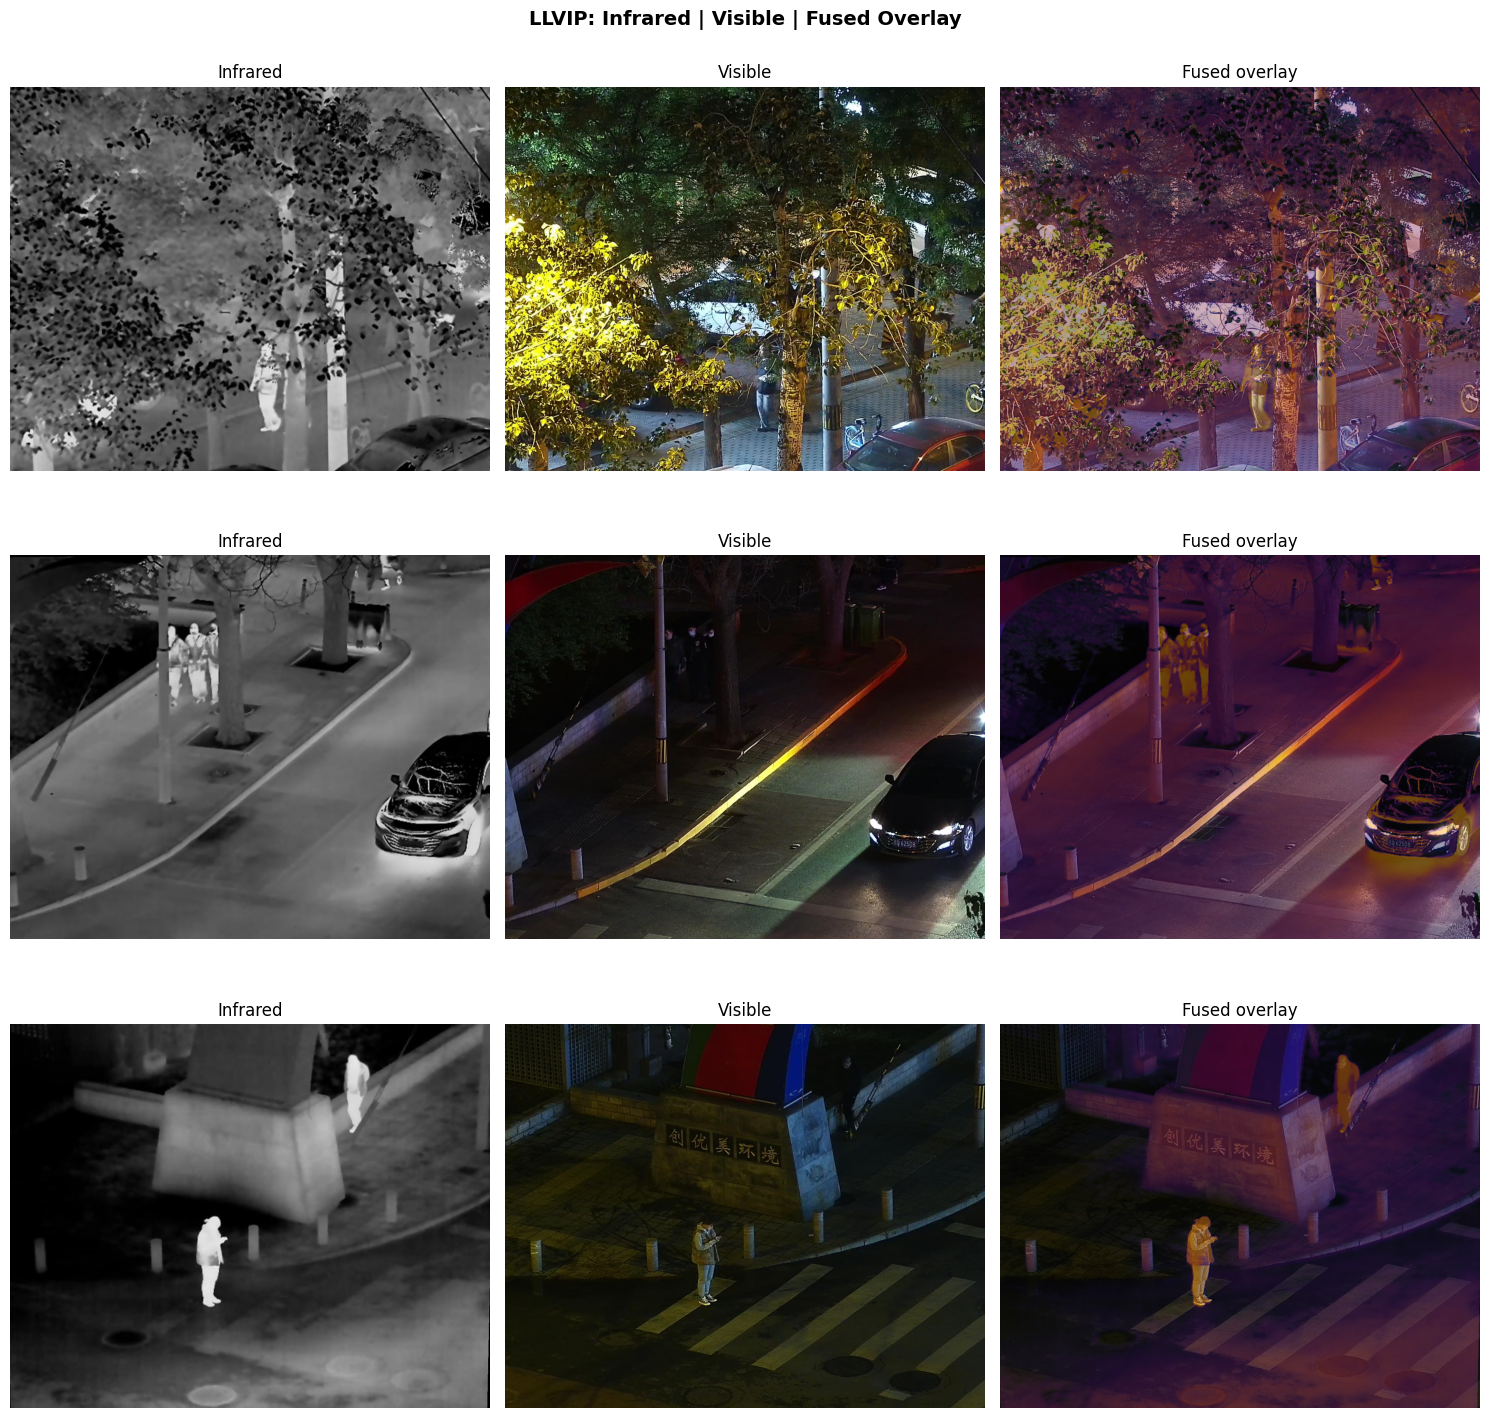

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
fig.suptitle("LLVIP: Infrared | Visible | Fused Overlay", fontsize=14, fontweight="bold")

for row, idx in enumerate(sample_idx):
    ir_gray = cv2.imread(str(all_ir_train[idx]), cv2.IMREAD_GRAYSCALE)
    vis_bgr = cv2.imread(str(all_vis_train[idx]))
    if ir_gray is None or vis_bgr is None:
        raise FileNotFoundError(f"Could not read pair: {all_ir_train[idx].name}")

    vis_rgb = cv2.cvtColor(vis_bgr, cv2.COLOR_BGR2RGB)
    heatmap = cv2.applyColorMap(ir_gray, cv2.COLORMAP_INFERNO)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    vis_resized = cv2.resize(vis_rgb, (ir_gray.shape[1], ir_gray.shape[0]))
    fused_overlay = cv2.addWeighted(vis_resized, 0.6, heatmap, 0.4, 0)

    axes[row, 0].imshow(ir_gray, cmap="gray")
    axes[row, 0].set_title("Infrared")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(vis_rgb)
    axes[row, 1].set_title("Visible")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(fused_overlay)
    axes[row, 2].set_title("Fused overlay")
    axes[row, 2].axis("off")

plt.tight_layout()
alignment_plot_path = results_dir / "section4_alignment_check.png"
plt.savefig(alignment_plot_path, dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
print(f"Saved alignment plot: {alignment_plot_path}")


Saved alignment plot: /home/vteam5/multispectral_pedestrian_ensemble/results/section4_alignment_check.png


# Preprocessing: Fusion, Label Conversion, data.yaml


In [ ]:
TARGET_RES = 1024
CLASS_ID = 0
TRAIN_RATIO = 0.85


In [ ]:
for split in ["train", "val"]:
    for subfolder in ["images", "labels"]:
        (processed_dataset_dir / split / subfolder).mkdir(parents=True, exist_ok=True)


In [ ]:
def convert_voc_xml_to_yolo(xml_path: Path, label_path: Path, fallback_w: int, fallback_h: int) -> int:
    """Convert one LLVIP XML annotation into one YOLO label file."""
    root = ElementTree.parse(str(xml_path)).getroot()

    size_node = root.find("size")
    if size_node is not None and size_node.find("width") is not None and size_node.find("height") is not None:
        image_w = int(float(size_node.find("width").text))
        image_h = int(float(size_node.find("height").text))
    else:
        image_w, image_h = fallback_w, fallback_h

    lines = []
    for obj in root.findall("object"):
        bb = obj.find("bndbox")
        xmin = float(bb.find("xmin").text)
        ymin = float(bb.find("ymin").text)
        xmax = float(bb.find("xmax").text)
        ymax = float(bb.find("ymax").text)

        cx = ((xmin + xmax) / 2) / image_w
        cy = ((ymin + ymax) / 2) / image_h
        bw = (xmax - xmin) / image_w
        bh = (ymax - ymin) / image_h
        cx, cy, bw, bh = [min(max(v, 0.0), 1.0) for v in (cx, cy, bw, bh)]
        lines.append(f"{CLASS_ID} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}")

    label_path.write_text("\n".join(lines))
    return len(lines)


In [ ]:
def create_fused_image(ir_path: Path, vis_path: Path, res: int = TARGET_RES) -> np.ndarray:
    """Create the saved YOLO input: IR plus visible green and blue channels."""
    ir_gray = cv2.imread(str(ir_path), cv2.IMREAD_GRAYSCALE)
    vis_bgr = cv2.imread(str(vis_path))
    if ir_gray is None or vis_bgr is None:
        raise FileNotFoundError(f"Could not read pair: {ir_path.name}")

    ir_resized = cv2.resize(ir_gray, (res, res), interpolation=cv2.INTER_AREA)
    vis_resized = cv2.resize(vis_bgr, (res, res), interpolation=cv2.INTER_AREA)
    return np.stack([ir_resized, vis_resized[:, :, 1], vis_resized[:, :, 0]], axis=2).astype(np.uint8)


In [ ]:
paired_stems = [p.stem for p in all_ir_train
                if (llvip_visible_train_dir / (p.stem + ".jpg")).exists()]

random.seed(42)
random.shuffle(paired_stems)
n_train = int(len(paired_stems) * TRAIN_RATIO)
split_stems = {"train": paired_stems[:n_train], "val": paired_stems[n_train:]}

print(f"Total pairs: {len(paired_stems)}")
print(f"Training split: {len(split_stems['train'])}")
print(f"Validation split: {len(split_stems['val'])}")


Total pairs: 12025
Training split: 10221
Validation split: 1804


In [ ]:
expected_train = len(split_stems["train"])
expected_val = len(split_stems["val"])
current_train_images = len(list((processed_dataset_dir / "train" / "images").glob("*.jpg")))
current_train_labels = len(list((processed_dataset_dir / "train" / "labels").glob("*.txt")))
current_val_images = len(list((processed_dataset_dir / "val" / "images").glob("*.jpg")))
current_val_labels = len(list((processed_dataset_dir / "val" / "labels").glob("*.txt")))

preprocessing_complete = (
    current_train_images >= expected_train and current_train_labels >= expected_train and
    current_val_images >= expected_val and current_val_labels >= expected_val
)

if preprocessing_complete:
    print("Processed dataset already looks complete. Skipping image and label creation.")
else:
    print("Creating missing fused images and YOLO labels.")
    total_imgs = 0
    total_boxes = 0

    for split, stems in split_stems.items():
        split_img_dir = processed_dataset_dir / split / "images"
        split_label_dir = processed_dataset_dir / split / "labels"

        for stem in stems:
            image_out = split_img_dir / f"{stem}.jpg"
            label_out = split_label_dir / f"{stem}.txt"
            if image_out.exists() and label_out.exists():
                continue

            ir_src = llvip_infrared_train_dir / f"{stem}.jpg"
            vis_src = llvip_visible_train_dir / f"{stem}.jpg"
            xml_src = llvip_annotations_dir / f"{stem}.xml"
            if not xml_src.exists():
                continue

            fused = create_fused_image(ir_src, vis_src, TARGET_RES)
            cv2.imwrite(str(image_out), fused)
            boxes = convert_voc_xml_to_yolo(xml_src, label_out, TARGET_RES, TARGET_RES)
            total_imgs += 1
            total_boxes += boxes

        print(f"{split}: checked {len(stems)} images")

    print(f"Images created or repaired: {total_imgs}")
    print(f"Boxes written: {total_boxes}")


Processed dataset already looks complete. Skipping image and label creation.


In [ ]:
data_yaml_path = processed_dataset_dir / "data.yaml"
data_yaml = {
    "path": str(processed_dataset_dir),
    "train": "train/images",
    "val": "val/images",
    "nc": 1,
    "names": ["Pedestrian"],
}

with open(data_yaml_path, "w") as f:
    yaml.dump(data_yaml, f, default_flow_style=False, sort_keys=False)

print(f"data.yaml saved: {data_yaml_path}")


data.yaml saved: /home/vteam5/multispectral_pedestrian_ensemble/processed_dataset/data.yaml
